## Principal Component Analysis (PCA)

The motivation of Principal Component Analysis (PCA) is to find a new set of features that are ordered by the amount of variation (and therefore, information) they contain. We can then select a subset of these PCA features. This leaves us with lower-dimensional data that still retains most of the information contained in the larger dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_olivetti_faces



In [8]:

# Load your dataset
faces = fetch_olivetti_faces()
df = pd.DataFrame(faces.data)
df['Class'] = faces.target
df.dropna()

#1. Print the DataFrame head
print(df.head())

#2. Extract the numerical columns
data_matrix = df.drop(columns = ['Class'])

# Extract the classes
classes = df['Class']




          0         1         2         3         4         5         6  \
0  0.309917  0.367769  0.417355  0.442149  0.528926  0.607438  0.657025   
1  0.454545  0.471074  0.512397  0.557851  0.595041  0.640496  0.681818   
2  0.318182  0.400826  0.491736  0.528926  0.586777  0.657025  0.681818   
3  0.198347  0.194215  0.194215  0.194215  0.190083  0.190083  0.243802   
4  0.500000  0.545455  0.582645  0.623967  0.648760  0.690083  0.694215   

          7         8         9  ...      4087      4088      4089      4090  \
0  0.677686  0.690083  0.685950  ...  0.669421  0.652893  0.661157  0.475207   
1  0.702479  0.710744  0.702479  ...  0.157025  0.136364  0.148760  0.152893   
2  0.685950  0.702479  0.698347  ...  0.132231  0.181818  0.136364  0.128099   
3  0.404959  0.483471  0.516529  ...  0.636364  0.657025  0.685950  0.727273   
4  0.714876  0.723140  0.731405  ...  0.161157  0.177686  0.173554  0.177686   

       4091      4092      4093      4094      4095  Class  
0  0.13

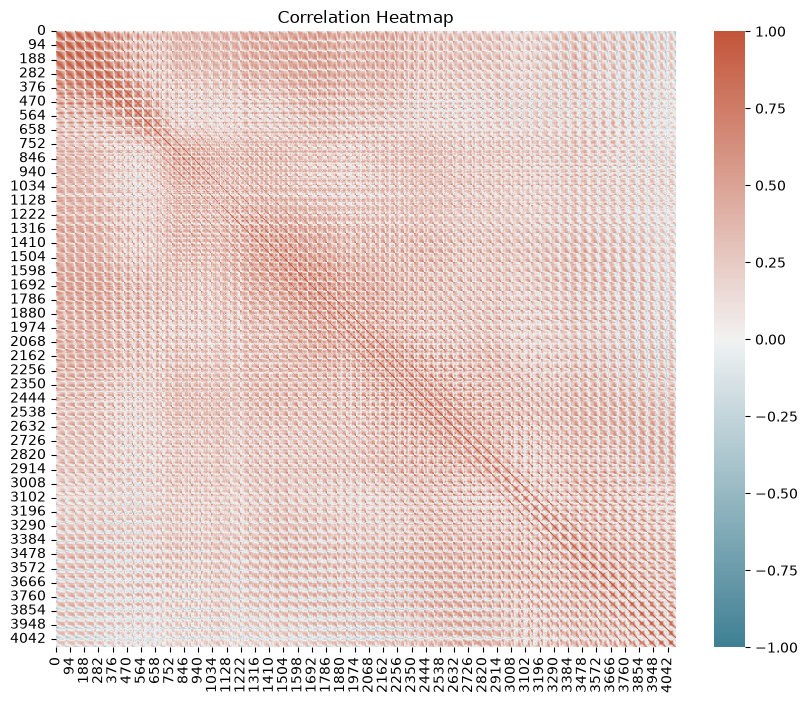

Eigenvalues:
 [ 1.10085933e+03+0.00000000e+00j  5.05543740e+02+0.00000000e+00j
  3.21183975e+02+0.00000000e+00j ...  1.01945119e-15+0.00000000e+00j
 -1.04554422e-15+3.33890957e-17j -1.04554422e-15-3.33890957e-17j]

Eigenvectors shape: (4096, 4096)

Information proportions:
 [ 2.68764484e-01-1.35875661e-33j  1.23423765e-01-6.23977000e-34j
  7.84140564e-02-3.96427446e-34j ...  2.48889452e-19-1.25827708e-51j
 -2.55259820e-19+8.15163469e-21j -2.55259820e-19-8.15163469e-21j]


In [9]:

# 1. Compute correlation matrix
correlation_matrix = data_matrix.corr()

# Heatmap of correlations
plt.figure(figsize=(10, 8))
red_blue = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(correlation_matrix, vmin=-1, vmax=1, cmap=red_blue, annot=False)
plt.title("Correlation Heatmap")
plt.show()

# 2. Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix)

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors shape:", eigenvectors.shape)

# 3. Information proportion (variance explained by each PC)
info_prop = eigenvalues / eigenvalues.sum()
print("\nInformation proportions:\n", info_prop)


c:\Users\apexf\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\apexf\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


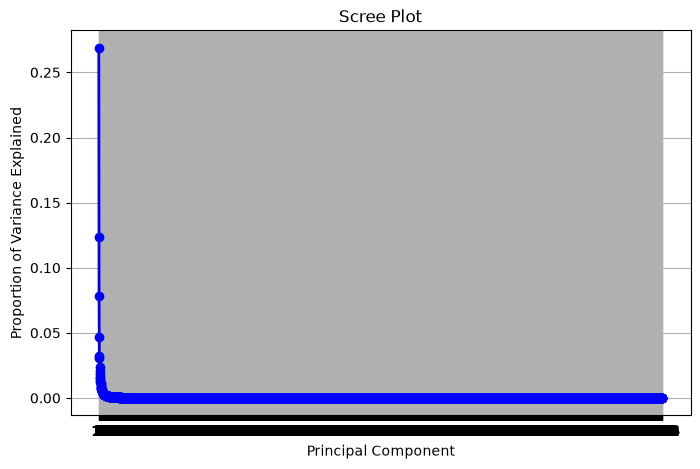


Cumulative proportions:
 [0.26876448-1.35875661e-33j 0.39218825-1.98273361e-33j
 0.4706023 -2.37916106e-33j ... 1.        -4.62223187e-33j
 1.        +8.15163469e-21j 1.        -4.62223187e-33j]


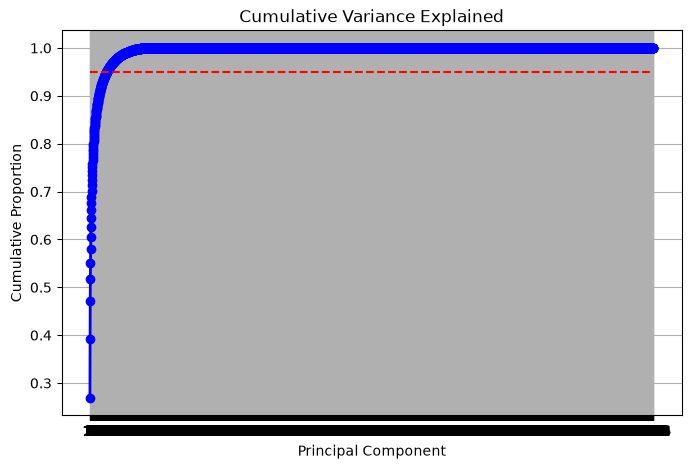

In [10]:

# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(info_prop)+1), info_prop, 'bo-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.xticks(np.arange(1, len(info_prop)+1))
plt.ylabel('Proportion of Variance Explained')
plt.grid(True)
plt.show()

# 4. Cumulative variance explained
cum_info_prop = np.cumsum(info_prop)
print("\nCumulative proportions:\n", cum_info_prop)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_info_prop)+1), cum_info_prop, 'bo-', linewidth=2)
plt.hlines(y=0.95, xmin=0, xmax=len(cum_info_prop), colors='r', linestyles='dashed')
plt.title('Cumulative Variance Explained')
plt.xlabel('Principal Component')
plt.xticks(np.arange(1, len(info_prop)+1))
plt.ylabel('Cumulative Proportion')
plt.grid(True)
plt.show()


In [11]:

# 5. How many components to reach 95% variance?
num_components_95 = np.argmax(cum_info_prop >= 0.95) + 1
print(f"\nNumber of principal components needed for 95% variance: {num_components_95}")



Number of principal components needed for 95% variance: 123
